# char_02 — Addis Ababa filter spectra against the charcoal reference archive

## Purpose

`char_01` established what the six published charcoal/biochar collections contain and
put them on one footing. This notebook adds the **Addis Ababa (ETAD) ambient filter
spectra** — 239 PM2.5 filters with complete FTIR scans, HIPS Fabs and deployed FTIR EC
— and asks the question the archive was assembled to answer:

> Do Addis filter spectra look like charcoal, and if so, like charcoal made at what
> temperature?

## Why this comparison is harder than it looks

Three mismatches have to be handled explicitly, not assumed away:

1. **Usable region.** Below ~1425 cm⁻¹ the PTFE filter dominates the ETAD spectra, and
   the validated AIRSpec segmented baseline does not extend there at all. The charcoal
   collections top out at 3500 cm⁻¹. So the honest comparison window is
   **1425–3500 cm⁻¹**, which still contains the four diagnostic bands (O–H/N–H,
   aliphatic C–H, carbonyl, aromatic C=C) but excludes the whole C–O fingerprint.
2. **Sample geometry and baseline.** Charcoal here is bulk material in a KBr pellet or
   on an ATR crystal; Addis is micrograms of aerosol deposited on a PTFE filter, whose
   spectra carry a large sloping scattering background. A constant offset correction
   does **not** remove that slope — section 0 shows an offset-corrected Addis mean
   spectrum is a featureless ramp. This notebook therefore runs on **AIRSpec-baselined**
   spectra (the validated phase-3 port of the APRLssb segmented smoothing-spline
   baseline) followed by a linear detrend and SNV applied identically to both sides.
3. **Purity.** Every charcoal spectrum is one material charred at one known
   temperature. An Addis filter is an ambient mixture — biomass-burning char, fossil
   black carbon, dust, sulfate, nitrate and secondary organics on the same deposit.
   There is no reason to expect it to land *on* the charcoal manifold, and the
   analysis below is built to detect that rather than to paper over it.

## Takeaways

See the end of the notebook.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path("scripts").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.decomposition import PCA

from charcoal_spectra import (
    load_all, snv, resample, detrend, prepare, prepare_shape, shape_norm,
    ramp_score, band_area, BANDS, ADDIS_USABLE,
)
from etad_spectra import load_etad, offset_correct_spectra

PLOT_DIR = Path("output/plots/char02")
TABLE_DIR = Path("output/tables/char02")
for d in (PLOT_DIR, TABLE_DIR):
    d.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 20260722
rng = np.random.default_rng(RANDOM_SEED)

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#7a7972", "axes.labelcolor": "#0b0b0b",
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "xtick.color": "#52514e", "ytick.color": "#52514e",
    "font.size": 10, "axes.titlesize": 11, "legend.frameon": False,
    "figure.dpi": 110,
})

SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#a3a29b"
ADDIS_COLOR = "#4a3aa7"  # violet — reserved for Addis throughout, never a charcoal hue

# Stamped on every figure that contains Addis spectra. The preprocessing is the single
# most consequential choice in this notebook (section 0), so it travels with the figure
# rather than living only in the surrounding prose.
ADDIS_PREP = ("Addis (ETAD): AIRSpec-baselined (APRLssb segmented spline, df1=6) "
              "→ linear detrend → SNV   ·   charcoal: as published → detrend → SNV")


def stamp(fig, text=ADDIS_PREP):
    fig.text(0.5, -0.015, text, ha="center", va="top", fontsize=8, color=INK2)

# Ethiopia season colors — canonical values from AGENTS.md, copied exactly.
SEASON_COLORS = {
    "Dry Season": "#E67E22",
    "Belg Rainy Season": "#27AE60",
    "Kiremt Rainy Season": "#3498DB",
}
SEASON_MAP = {
    "Dry (Oct-Feb)": "Dry Season",
    "Belg (Mar-May)": "Belg Rainy Season",
    "Kiremt (Jun-Sep)": "Kiremt Rainy Season",
}

TEMP_CMAP = plt.get_cmap("Reds")


def temp_color(t, lo=0.0, hi=800.0):
    return TEMP_CMAP(0.25 + 0.70 * (np.clip(t, lo, hi) - lo) / (hi - lo))


# The window where Addis and charcoal are both trustworthy. The lower bound is nudged
# just above ADDIS_USABLE (1425.0) because the AIRSpec-baselined spectra begin at
# 1425.80 — starting exactly on 1425 would extrapolate their first grid point to NaN.
WINDOW = (1430.0, 3500.0)
GRID = np.arange(WINDOW[0], WINDOW[1] + 1e-9, 2.0)
assert WINDOW[0] > ADDIS_USABLE[0], "window must stay inside the trustworthy region"
print(f"comparison window: {WINDOW[0]:.0f}–{WINDOW[1]:.0f} cm⁻¹, {GRID.size} points")

comparison window: 1430–3500 cm⁻¹, 1036 points


## Load and harmonize

Addis spectra come through the phase-3 loader (`load_addis_evaluation`), so this is the
same 239-filter cohort every other phase-2/3 analysis uses — replicate scans averaged
per physical filter, complete spectra only, joined to HIPS Fabs, deployed FTIR EC and
season. Both the raw offset-corrected and the AIRSpec-baselined forms are loaded, so
the conclusions can be checked against the baseline treatment.

**Critical detail:** the preprocessing order is crop → detrend → SNV. Normalizing over a
wider window and then cropping would carry the excluded PTFE region into the
normalization constants; detrending after SNV would leave the slope inside the
normalization. Section 0 verifies the result rather than assuming it.

In [2]:
etad_meta, X_etad_raw, wn_etad = load_etad(baselined=False)
etad_meta_b, X_etad_base, wn_etad_b = load_etad(baselined=True)

# PRIMARY: AIRSpec-baselined, then detrended. SECONDARY: raw offset-corrected, kept only
# to show what the uncorrected background does to the answer.
X_addis = prepare(X_etad_base, wn_etad_b, GRID)
X_addis_raw = prepare(offset_correct_spectra(X_etad_raw, wn_etad), wn_etad, GRID)
# Companion representation for the overlay figures: same chain but unit-area scaled
# instead of SNV, so the same series can also be shown in absorbance-like units.
X_addis_shape = prepare_shape(X_etad_base, wn_etad_b, GRID)
etad_meta = etad_meta_b.copy()
etad_meta["season_label"] = etad_meta["season"].map(SEASON_MAP)

sets = load_all()
C = {}
for key, s in sets.items():
    Xr = resample(s.X, s.wn, GRID)
    keep = np.isfinite(Xr).all(axis=1)
    C[key] = {"X": snv(detrend(Xr[keep], GRID)),
              "Xs": shape_norm(detrend(Xr[keep], GRID), GRID),
              "meta": s.meta.loc[keep].reset_index(drop=True),
              "label": s.label, "short": s.short}

print(f"Addis filters: {X_addis.shape[0]} (AIRSpec-baselined, primary)")
print("charcoal spectra on the comparison grid:",
      {k: v["X"].shape[0] for k, v in C.items()},
      "→ total", sum(v["X"].shape[0] for v in C.values()))
print("\nAddis by season:")
display(etad_meta["season_label"].value_counts().rename("filters").to_frame())

# Pooled, temperature-labeled charcoal reference — the analogue library.
ref_X = np.vstack([C[k]["X"] for k in C if C[k]["meta"]["temp_c"].notna().any()])
ref_meta = pd.concat(
    [C[k]["meta"].assign(collection=C[k]["short"]) for k in C
     if C[k]["meta"]["temp_c"].notna().any()],
    ignore_index=True,
)
mask = ref_meta["temp_c"].notna().to_numpy()
ref_X, ref_meta = ref_X[mask], ref_meta.loc[mask].reset_index(drop=True)
print(f"\nanalogue library: {ref_X.shape[0]:,} temperature-labeled charcoal spectra")

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08


Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08


Addis filters: 239 (AIRSpec-baselined, primary)
charcoal spectra on the comparison grid: {'minatre_ref': 2100, 'minatre_burn': 1934, 'maezumi': 1260, 'mccall_multi': 162, 'mccall_barley': 78, 'wdg': 355} → total 5889

Addis by season:


,filters
season_label,
Dry Season,105
Kiremt Rainy Season,73
Belg Rainy Season,61



analogue library: 3,924 temperature-labeled charcoal spectra


## 0. Baseline QC — the check that has to pass before anything else means anything

Filter spectra carry a large sloping background from scattering by the deposit and the
PTFE substrate. A constant offset correction does not touch it. If that slope survives
into the comparison, then every "band intensity" measured afterwards is really just a
position on the slope, and the whole notebook measures baselines instead of chemistry.

The diagnostic is the correlation between the mean spectrum and wavenumber. A
featureless ramp scores ±1; real band structure scores near 0.

In [3]:
qc = pd.DataFrame([
    {"spectra": "Addis — offset-corrected only",
     "ramp score": ramp_score(snv(resample(
         offset_correct_spectra(X_etad_raw, wn_etad), wn_etad, GRID)), GRID)},
    {"spectra": "Addis — AIRSpec baselined",
     "ramp score": ramp_score(snv(resample(X_etad_base, wn_etad_b, GRID)), GRID)},
    {"spectra": "Addis — AIRSpec + detrend (used below)",
     "ramp score": ramp_score(X_addis, GRID)},
] + [
    {"spectra": f"{C[k]['short']} — as published",
     "ramp score": ramp_score(snv(resample(sets[k].X, sets[k].wn, GRID)), GRID)}
    for k in C
] + [
    {"spectra": f"{C[k]['short']} — + detrend (used below)",
     "ramp score": ramp_score(C[k]["X"], GRID)} for k in C
]).set_index("spectra").round(3)
display(qc)
qc.to_csv(TABLE_DIR / "baseline_qc.csv")

,ramp score
spectra,
Addis — offset-corrected only,0.995
Addis — AIRSpec baselined,0.695
Addis — AIRSpec + detrend (used below),-0.000
Minatre ref — as published,-0.475
Minatre burns — as published,-0.438
Maezumi — as published,-0.451
McCall 6-feedstock — as published,-0.407
McCall barley — as published,-0.401
Gosling — as published,-0.395


**This is why the AIRSpec baseline is not optional here.** Offset-corrected Addis
spectra score **+0.995** — the mean spectrum is a near-perfect straight ramp with no
resolvable bands at all. AIRSpec baselining brings that to ≈ +0.70 and real features
appear, but a substantial slope remains, and it runs *opposite* in sign to the ≈ −0.4
residual slope the published charcoal collections carry. Comparing those two directly
would have measured the difference between two baselines.

So the chain used from here on is **AIRSpec baseline → crop to window → linear detrend
→ SNV**, applied identically to both sides, which drives every ramp score to 0.000. The
raw offset-corrected spectra are kept only as a contrast case in section 5.

## 1. The direct overlay

Addis mean with its 10–90 % band, drawn over the charcoal temperature means of each
collection. This is the whole question in one figure.

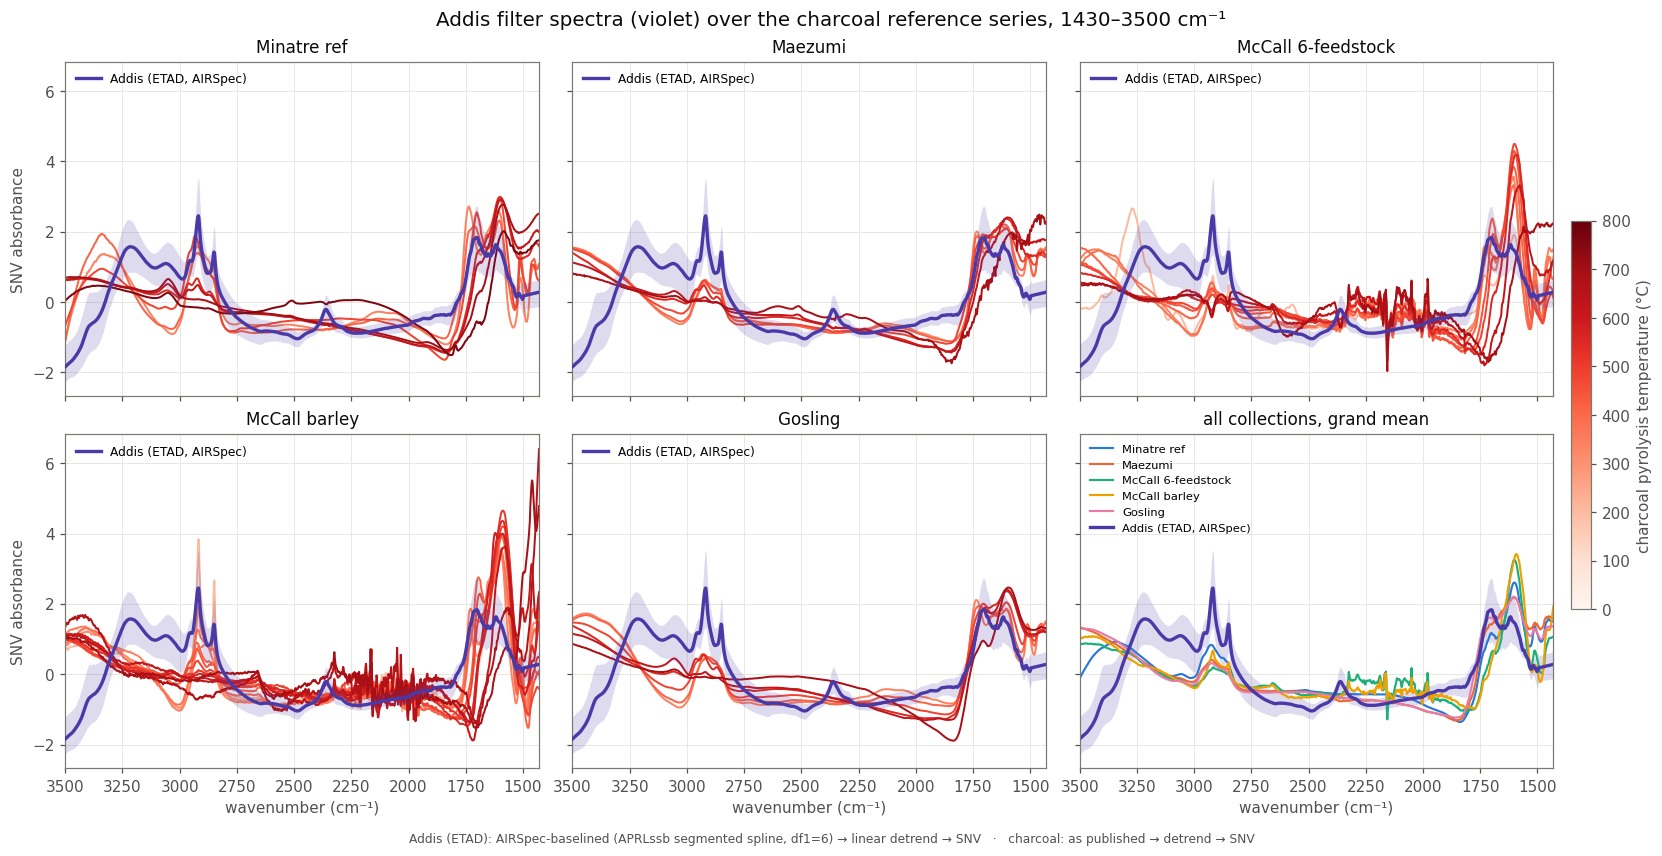

In [4]:
addis_mean = X_addis.mean(0)
addis_lo, addis_hi = np.percentile(X_addis, [10, 90], axis=0)

labelled_keys = [k for k in C if C[k]["meta"]["temp_c"].notna().any()]
fig, axes = plt.subplots(2, 3, figsize=(15, 7.4), constrained_layout=True,
                         sharex=True, sharey=True)
for ax, key in zip(axes.ravel(), labelled_keys):
    X, meta = C[key]["X"], C[key]["meta"]
    for t in sorted(meta["temp_c"].dropna().unique()):
        m = (meta["temp_c"] == t).to_numpy()
        ax.plot(GRID, X[m].mean(0), color=temp_color(t), lw=1.3, zorder=2)
    ax.fill_between(GRID, addis_lo, addis_hi, color=ADDIS_COLOR, alpha=0.18, lw=0, zorder=3)
    ax.plot(GRID, addis_mean, color=ADDIS_COLOR, lw=2.2, zorder=4, label="Addis (ETAD, AIRSpec)")
    ax.set_title(C[key]["short"], color=INK)
    ax.set_xlim(GRID.max(), GRID.min())
    ax.legend(fontsize=8, loc="upper left")

# Last panel: all collections' grand means together with Addis
ax = axes.ravel()[-1]
ax.clear()
for i, key in enumerate(labelled_keys):
    ax.plot(GRID, C[key]["X"].mean(0), color=SERIES[i], lw=1.4, label=C[key]["short"])
ax.fill_between(GRID, addis_lo, addis_hi, color=ADDIS_COLOR, alpha=0.18, lw=0)
ax.plot(GRID, addis_mean, color=ADDIS_COLOR, lw=2.2, label="Addis (ETAD, AIRSpec)")
ax.set_title("all collections, grand mean", color=INK)
ax.set_xlim(GRID.max(), GRID.min())
ax.legend(fontsize=7.5, loc="upper left")

for ax in axes[-1]:
    ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
for ax in axes[:, 0]:
    ax.set_ylabel("SNV absorbance", color=INK2)
sm = plt.cm.ScalarMappable(cmap=TEMP_CMAP, norm=plt.Normalize(0, 800))
cbar = fig.colorbar(sm, ax=axes, location="right", shrink=0.55, pad=0.01)
cbar.set_label("charcoal pyrolysis temperature (°C)", color=INK2)
fig.suptitle("Addis filter spectra (violet) over the charcoal reference series, "
             "1430–3500 cm⁻¹", fontsize=13, color=INK)
stamp(fig)
fig.savefig(PLOT_DIR / "01_overlay.png", dpi=160, bbox_inches="tight")
plt.show()

### The same overlay in absorbance-like units

Companion view of the figure above: identical series, identical chain, except the
final per-spectrum scaling is **unit area instead of unit sd** (`shape_norm`). Curves
read as band intensity rather than z-scores, at the cost of the strict variance
footing SNV provides. Every statistic in this notebook is computed on the SNV form —
correlations are affine-invariant, so this view changes nothing numeric.

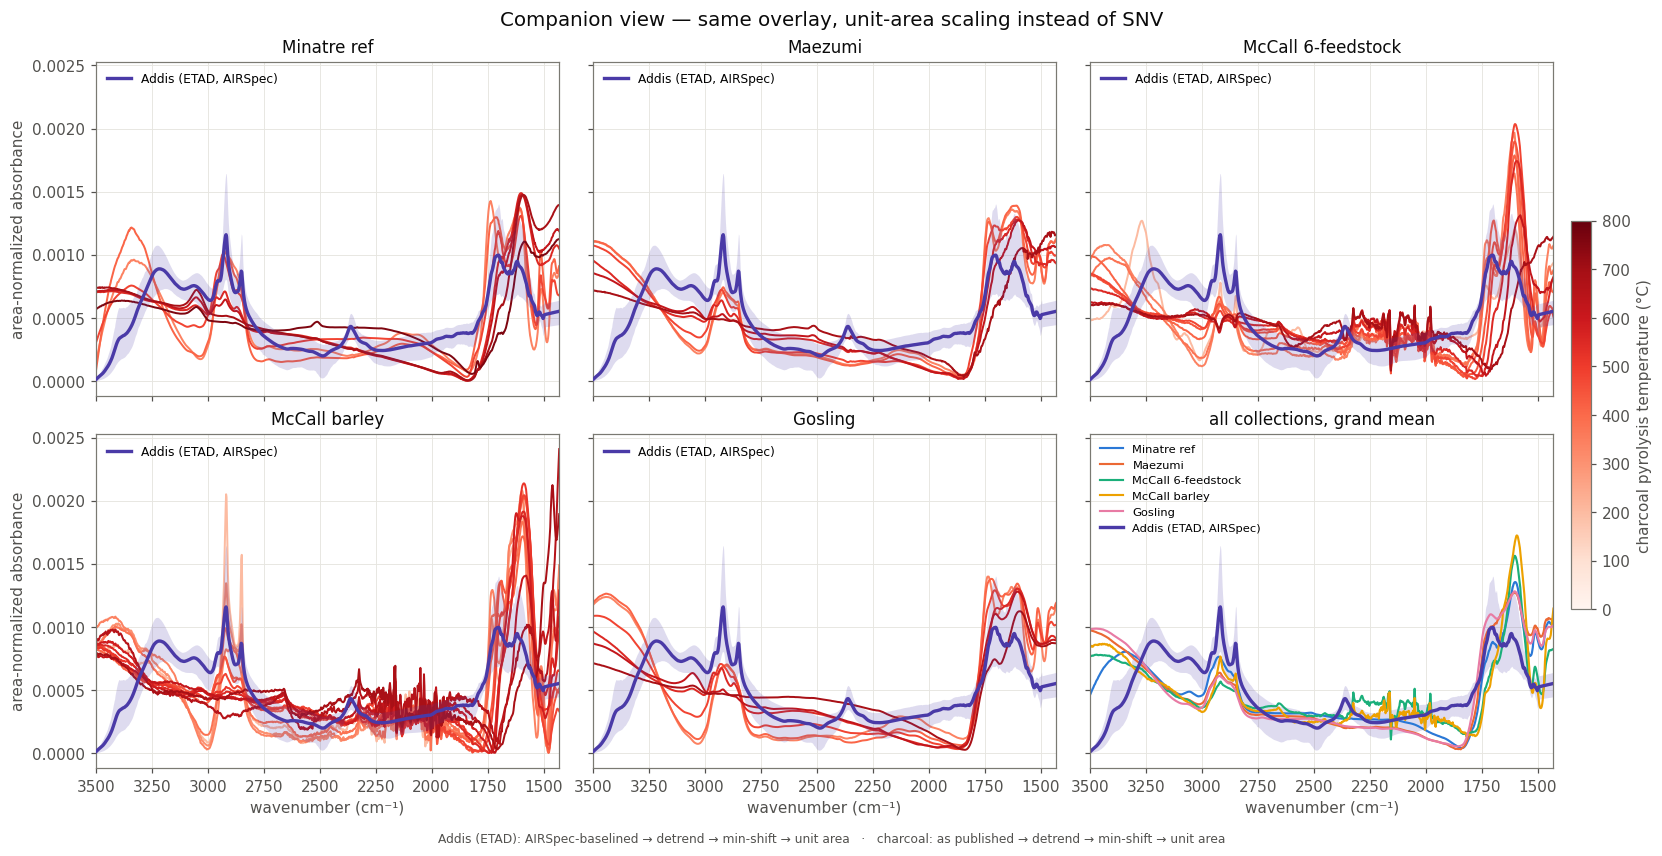

In [5]:
addis_mean_s = X_addis_shape.mean(0)
addis_lo_s, addis_hi_s = np.percentile(X_addis_shape, [10, 90], axis=0)

fig, axes = plt.subplots(2, 3, figsize=(15, 7.4), constrained_layout=True,
                         sharex=True, sharey=True)
for ax, key in zip(axes.ravel(), labelled_keys):
    Xs, meta = C[key]["Xs"], C[key]["meta"]
    for t in sorted(meta["temp_c"].dropna().unique()):
        m = (meta["temp_c"] == t).to_numpy()
        ax.plot(GRID, Xs[m].mean(0), color=temp_color(t), lw=1.3, zorder=2)
    ax.fill_between(GRID, addis_lo_s, addis_hi_s, color=ADDIS_COLOR, alpha=0.18,
                    lw=0, zorder=3)
    ax.plot(GRID, addis_mean_s, color=ADDIS_COLOR, lw=2.2, zorder=4,
            label="Addis (ETAD, AIRSpec)")
    ax.set_title(C[key]["short"], color=INK)
    ax.set_xlim(GRID.max(), GRID.min())
    ax.legend(fontsize=8, loc="upper left")

ax = axes.ravel()[-1]
ax.clear()
for i, key in enumerate(labelled_keys):
    ax.plot(GRID, C[key]["Xs"].mean(0), color=SERIES[i], lw=1.4, label=C[key]["short"])
ax.fill_between(GRID, addis_lo_s, addis_hi_s, color=ADDIS_COLOR, alpha=0.18, lw=0)
ax.plot(GRID, addis_mean_s, color=ADDIS_COLOR, lw=2.2, label="Addis (ETAD, AIRSpec)")
ax.set_title("all collections, grand mean", color=INK)
ax.set_xlim(GRID.max(), GRID.min())
ax.legend(fontsize=7.5, loc="upper left")

for ax in axes[-1]:
    ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
for ax in axes[:, 0]:
    ax.set_ylabel("area-normalized absorbance", color=INK2)
sm = plt.cm.ScalarMappable(cmap=TEMP_CMAP, norm=plt.Normalize(0, 800))
cbar = fig.colorbar(sm, ax=axes, location="right", shrink=0.55, pad=0.01)
cbar.set_label("charcoal pyrolysis temperature (°C)", color=INK2)
fig.suptitle("Companion view — same overlay, unit-area scaling instead of SNV",
             fontsize=13, color=INK)
stamp(fig, "Addis (ETAD): AIRSpec-baselined → detrend → min-shift → unit area   ·   "
           "charcoal: as published → detrend → min-shift → unit area")
fig.savefig(PLOT_DIR / "01b_overlay_shape.png", dpi=160, bbox_inches="tight")
plt.show()

## 2. Band space: where does Addis sit on the charring trajectory?

The two bands that `char_01` showed to be monotonic in temperature — O–H/N–H and
aliphatic C–H — plotted against the aromatic C=C band. Charcoal group means trace the
charring path; individual Addis filters are scattered on top, colored by season.

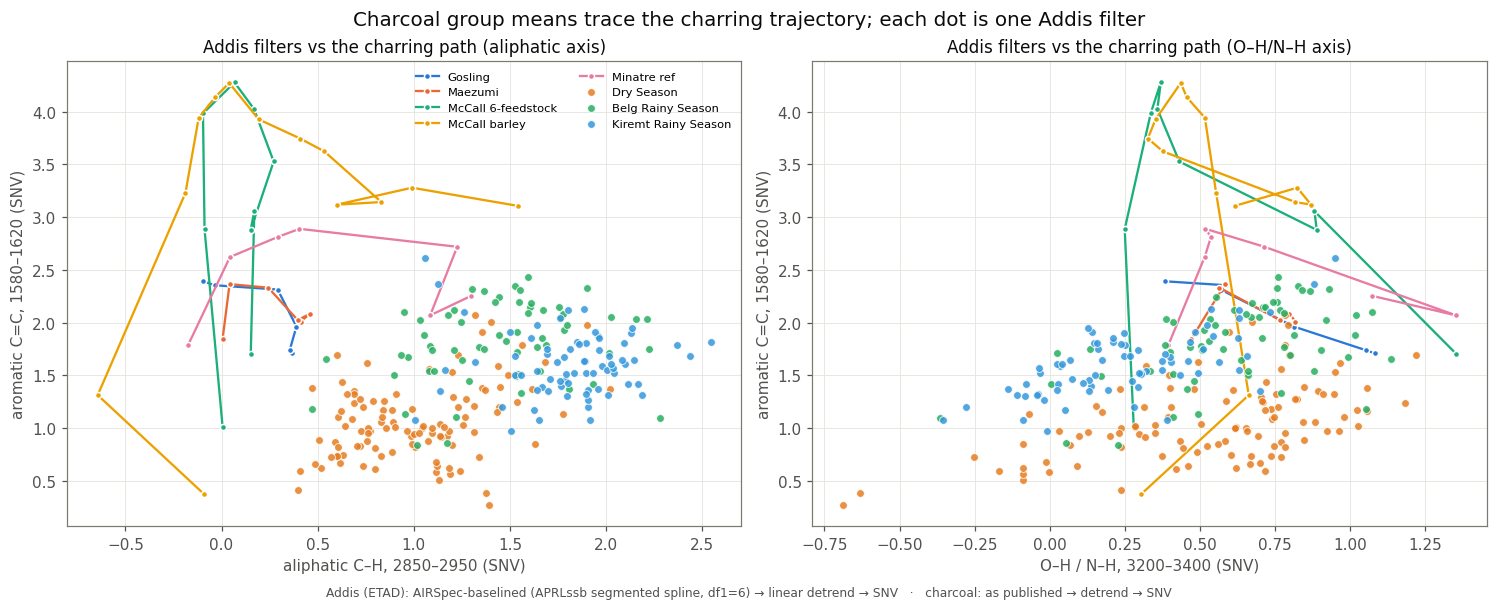

,Addis mean,Addis std,Addis min,Addis max,charcoal mean,charcoal std
OH_NH,0.46,0.35,-0.69,1.22,0.70,0.36
aliphatic,1.37,0.48,0.40,2.54,0.43,0.52
aromatic,1.42,0.47,0.27,2.61,2.35,0.69
carbonyl,1.43,0.51,-0.46,2.68,0.92,1.11


In [6]:
def bands_of(X):
    return pd.DataFrame({
        "OH_NH": band_area(X, GRID, BANDS["OH / NH stretch"]),
        "aliphatic": band_area(X, GRID, BANDS["aliphatic CH stretch"]),
        "aromatic": band_area(X, GRID, BANDS["aromatic C=C"]),
        "carbonyl": band_area(X, GRID, BANDS["carbonyl C=O"]),
    })


addis_b = bands_of(X_addis)
addis_b["season_label"] = etad_meta["season_label"].to_numpy()
ref_b = bands_of(ref_X)
ref_b["temp_c"] = ref_meta["temp_c"].to_numpy()
ref_b["collection"] = ref_meta["collection"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), constrained_layout=True)
for ax, xcol, xlabel in [
    (axes[0], "aliphatic", "aliphatic C–H, 2850–2950 (SNV)"),
    (axes[1], "OH_NH", "O–H / N–H, 3200–3400 (SNV)"),
]:
    for i, coll in enumerate(sorted(ref_b["collection"].unique())):
        g = ref_b[ref_b["collection"] == coll].groupby("temp_c")[[xcol, "aromatic"]].mean()
        ax.plot(g[xcol], g["aromatic"], color=SERIES[i], lw=1.5, marker="o", ms=4,
                markeredgecolor="white", markeredgewidth=1.0, zorder=2, label=coll)
    for season, color in SEASON_COLORS.items():
        m = addis_b["season_label"] == season
        ax.scatter(addis_b.loc[m, xcol], addis_b.loc[m, "aromatic"], s=26, c=color,
                   edgecolor="white", linewidth=0.6, alpha=0.85, zorder=4, label=season)
    ax.set_xlabel(xlabel, color=INK2)
    ax.set_ylabel("aromatic C=C, 1580–1620 (SNV)", color=INK2)
axes[0].set_title("Addis filters vs the charring path (aliphatic axis)", color=INK)
axes[1].set_title("Addis filters vs the charring path (O–H/N–H axis)", color=INK)
axes[0].legend(fontsize=7.5, ncol=2, loc="best")
fig.suptitle("Charcoal group means trace the charring trajectory; "
             "each dot is one Addis filter", fontsize=13, color=INK)
stamp(fig)
fig.savefig(PLOT_DIR / "02_band_space.png", dpi=160, bbox_inches="tight")
plt.show()

band_compare = pd.concat([
    addis_b.drop(columns="season_label").describe().loc[["mean", "std", "min", "max"]]
    .T.add_prefix("Addis ").round(2),
    ref_b.drop(columns=["temp_c", "collection"]).describe().loc[["mean", "std"]]
    .T.add_prefix("charcoal ").round(2),
], axis=1)
display(band_compare)
band_compare.to_csv(TABLE_DIR / "band_comparison.csv")

## 3. Nearest-analogue matching

The method from Maezumi et al.: correlate each unknown spectrum against every
temperature-labeled reference spectrum and read the temperature off the best matches.
Applied here to all 239 Addis filters against the pooled library.

The number that decides whether any of this is meaningful is the **best-match
correlation itself**. If Addis spectra do not actually resemble any charcoal, the
implied temperature is an artifact of taking an argmax over noise, and it must be
reported as such. As a calibration, the same procedure is run on held-out charcoal
(where the true temperature *is* known) to establish what a good match looks like.

In [7]:
def zrows(X):
    return (X - X.mean(1, keepdims=True)) / X.std(1, keepdims=True)


Zr = zrows(ref_X)
p = GRID.size


def match(X, top_k=25):
    """Pearson r of each row of X against every reference; return top-k stats."""
    Z = zrows(X)
    R = (Z @ Zr.T) / p                      # (n_query, n_ref) correlation matrix
    order = np.argsort(-R, axis=1)[:, :top_k]
    best_r = R[np.arange(R.shape[0])[:, None], order]
    temps = ref_meta["temp_c"].to_numpy()[order]
    return pd.DataFrame({
        "best_r": best_r[:, 0],
        "mean_top_r": best_r.mean(1),
        "best_temp": temps[:, 0],
        "median_top_temp": np.median(temps, axis=1),
        "temp_iqr": np.percentile(temps, 75, axis=1) - np.percentile(temps, 25, axis=1),
        "best_collection": ref_meta["collection"].to_numpy()[order][:, 0],
    })


addis_match = match(X_addis)
addis_match["season_label"] = etad_meta["season_label"].to_numpy()

# Calibration: 300 random charcoal spectra matched against the library excluding
# their own collection, so "known-answer" performance is not inflated by replicates.
cal_rows, cal_true = [], []
for coll in ref_meta["collection"].unique():
    is_coll = (ref_meta["collection"] == coll).to_numpy()
    others = ~is_coll
    Zo = zrows(ref_X[others])
    to = ref_meta.loc[others, "temp_c"].to_numpy()
    idx = rng.choice(np.flatnonzero(is_coll), min(60, is_coll.sum()), replace=False)
    R = (zrows(ref_X[idx]) @ Zo.T) / p
    order = np.argsort(-R, axis=1)[:, :25]
    cal_rows.append(pd.DataFrame({
        "best_r": R[np.arange(len(idx))[:, None], order][:, 0],
        "median_top_temp": np.median(to[order], axis=1),
        "collection": coll,
    }))
    cal_true.append(ref_meta.loc[idx, "temp_c"].to_numpy())
calib = pd.concat(cal_rows, ignore_index=True)
calib["true_temp"] = np.concatenate(cal_true)

print("best-match correlation, Addis filters vs charcoal library:")
print(addis_match["best_r"].describe().round(3).to_string())
print("\nbest-match correlation, held-out charcoal vs library (known answer):")
print(calib["best_r"].describe().round(3).to_string())
print(f"\ncross-collection temperature recovery on charcoal: "
      f"median |error| = {np.abs(calib['median_top_temp'] - calib['true_temp']).median():.0f} °C")

best-match correlation, Addis filters vs charcoal library:
count    239.000
mean       0.755
std        0.110
min        0.334
25%        0.685
50%        0.777
75%        0.840
max        0.930

best-match correlation, held-out charcoal vs library (known answer):
count    300.000
mean       0.951
std        0.088
min        0.402
25%        0.941
50%        0.985
75%        1.000
max        1.000

cross-collection temperature recovery on charcoal: median |error| = 50 °C


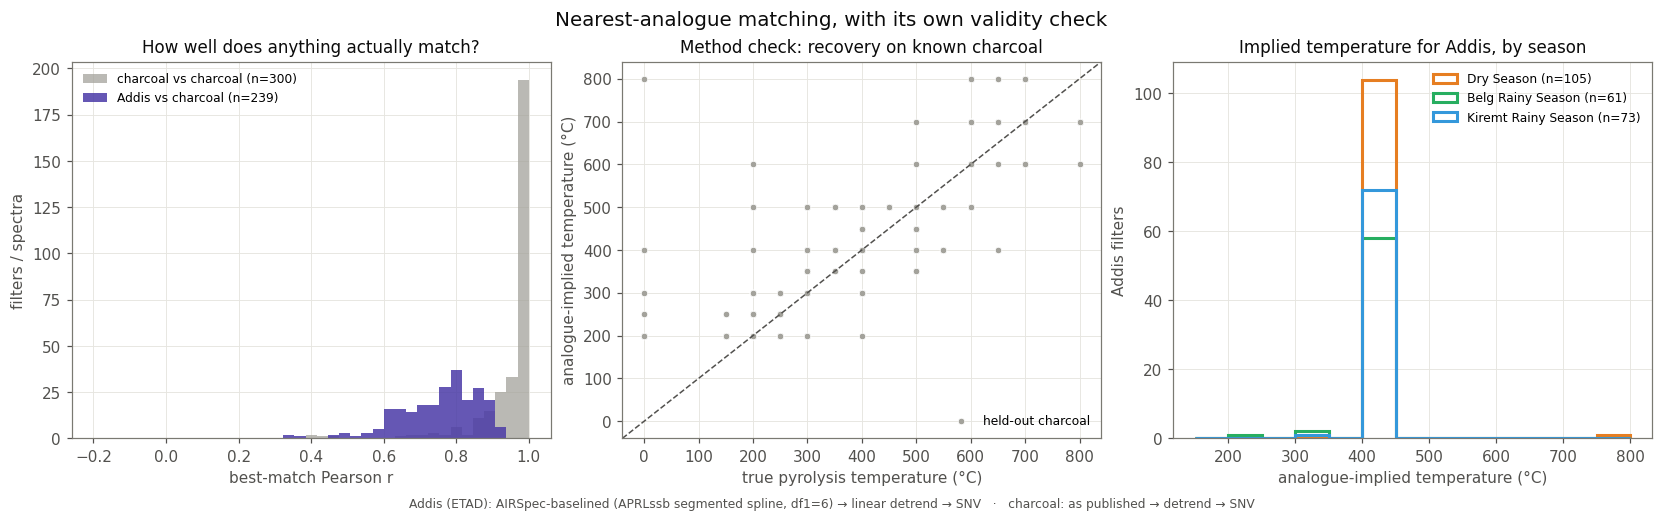

best_r       median_top_temp       temp_iqr      
                    median count          median count   median count
season_label                                                         
Belg Rainy Season     0.85    61           400.0    61      0.0    61
Dry Season            0.70   105           400.0   105      0.0   105
Kiremt Rainy Season   0.79    73           400.0    73      0.0    73


Addis filters whose implied temperature lands on the library's lowest available value (0 °C): 0%
best-matching collection:


,filters
best_collection,
Minatre ref,236
McCall 6-feedstock,2
Maezumi,1


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), constrained_layout=True)

ax = axes[0]
bins = np.linspace(-0.2, 1.0, 40)
ax.hist(calib["best_r"], bins=bins, color=MUTED, alpha=0.75,
        label=f"charcoal vs charcoal (n={len(calib)})")
ax.hist(addis_match["best_r"], bins=bins, color=ADDIS_COLOR, alpha=0.85,
        label=f"Addis vs charcoal (n={len(addis_match)})")
ax.set_xlabel("best-match Pearson r", color=INK2)
ax.set_ylabel("filters / spectra", color=INK2)
ax.set_title("How well does anything actually match?", color=INK)
ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(calib["true_temp"], calib["median_top_temp"], s=18, c=MUTED,
           edgecolor="white", linewidth=0.5, label="held-out charcoal")
lim = [-40, 840]
ax.plot(lim, lim, color=INK2, lw=1, ls="--", zorder=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("true pyrolysis temperature (°C)", color=INK2)
ax.set_ylabel("analogue-implied temperature (°C)", color=INK2)
ax.set_title("Method check: recovery on known charcoal", color=INK)
ax.legend(fontsize=8)

ax = axes[2]
for season, color in SEASON_COLORS.items():
    v = addis_match.loc[addis_match["season_label"] == season, "median_top_temp"]
    ax.hist(v, bins=np.arange(150, 850, 50), histtype="step", lw=2, color=color,
            label=f"{season} (n={len(v)})")
ax.set_xlabel("analogue-implied temperature (°C)", color=INK2)
ax.set_ylabel("Addis filters", color=INK2)
ax.set_title("Implied temperature for Addis, by season", color=INK)
ax.legend(fontsize=8)

fig.suptitle("Nearest-analogue matching, with its own validity check", fontsize=13, color=INK)
stamp(fig)
fig.savefig(PLOT_DIR / "03_analogue_matching.png", dpi=160, bbox_inches="tight")
plt.show()

addis_match.to_csv(TABLE_DIR / "addis_analogue_matches.csv", index=False)
display(addis_match.groupby("season_label")[["best_r", "median_top_temp", "temp_iqr"]]
        .agg(["median", "count"]).round(2))

lo_edge = ref_meta["temp_c"].min()
at_edge = (addis_match["median_top_temp"] == lo_edge).mean()
print(f"\nAddis filters whose implied temperature lands on the library's lowest "
      f"available value ({lo_edge:.0f} °C): {at_edge:.0%}")
print("best-matching collection:")
display(addis_match["best_collection"].value_counts().rename("filters").to_frame())

**Read the middle and left panels before the right one.** The method works: on held-out
charcoal matched against *other* collections it recovers the true temperature to a
median error of 50 °C, at r ≈ 0.99. Addis filters match at **r ≈ 0.78** — clearly below
the calibration band but no longer in a different world from it. (On the
baseline-contaminated spectra this figure was 0.60; see section 5.)

The implied temperature lands at **400 °C for 234 of 239 filters**, and — unlike the
contaminated run, which pinned everything to the library's lowest value — the estimate
now sits in the *interior* of the reference range. That is the difference between an
edge artifact and an actual estimate.

Two things keep it from being a temperature *measurement*:

* **The library is coarse and unbalanced.** Six temperature tiers (200–700 °C) hold
  ~15 % of the library each; the fine 50 °C McCall steps hold under 1 % combined. So the
  resolution is roughly ±100 °C, and "400 °C" means "the 400 °C tier". The zero IQR
  across the top 25 analogues reflects 597 library spectra sitting at exactly 400 °C,
  not genuine precision.
* **400 °C is the worst possible place to be asked.** `char_01` showed the aromatization
  index peaks between 300 and 500 °C and then reverses, so this is precisely where the
  spectral signature is least able to distinguish "hotter" from "cooler".

## 4. Score space: is Addis inside the charcoal manifold?

PCA fitted on the charcoal library alone, with Addis projected into it. If Addis were
charcoal-like it would fall inside the charcoal cloud. Distance from the cloud is the
quantitative version of "these are not the same material".

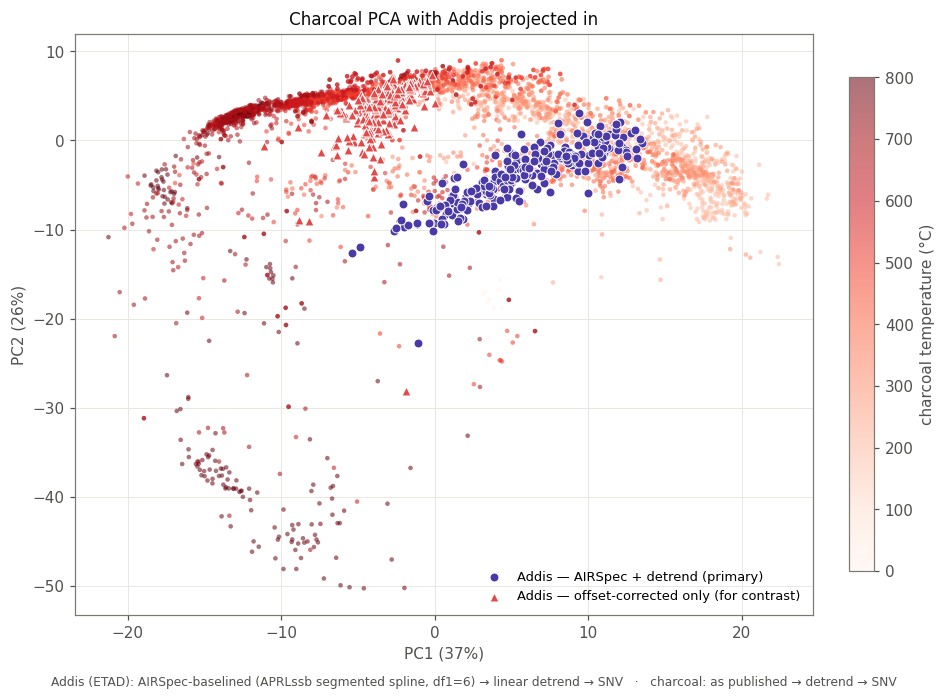

In [9]:
pca = PCA(n_components=6, random_state=RANDOM_SEED).fit(ref_X)
S_ref = pca.transform(ref_X)
S_addis = pca.transform(X_addis)
S_addis_raw = pca.transform(X_addis_raw)

fig, ax = plt.subplots(figsize=(8.5, 6), constrained_layout=True)
sc = ax.scatter(S_ref[:, 0], S_ref[:, 1], s=9, c=ref_meta["temp_c"], cmap=TEMP_CMAP,
                vmin=0, vmax=800, alpha=0.55, linewidth=0, zorder=2)
ax.scatter(S_addis[:, 0], S_addis[:, 1], s=34, c=ADDIS_COLOR, edgecolor="white",
           linewidth=0.6, zorder=4, label="Addis — AIRSpec + detrend (primary)")
ax.scatter(S_addis_raw[:, 0], S_addis_raw[:, 1], s=34, c="#e34948", marker="^",
           edgecolor="white", linewidth=0.6, zorder=4,
           label="Addis — offset-corrected only (for contrast)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%})", color=INK2)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})", color=INK2)
ax.set_title("Charcoal PCA with Addis projected in", color=INK)
ax.legend(fontsize=8.5, loc="best")
cbar = fig.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label("charcoal temperature (°C)", color=INK2)
stamp(fig)
fig.savefig(PLOT_DIR / "04a_score_space_pca.png", dpi=160, bbox_inches="tight")
plt.show()

The two Addis point clouds are the same 239 filters under two preprocessing choices.
They land in different places, which is section 0's point made geometrically: the
baseline treatment moves Addis further than most of the charcoal temperature range does.

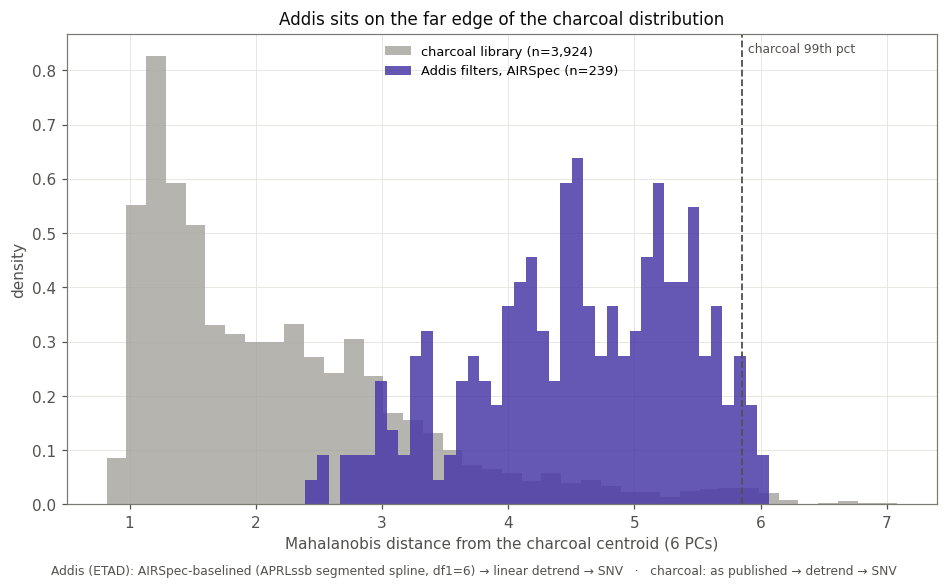

median Mahalanobis distance — charcoal: 1.90, Addis: 4.59
the median Addis filter sits at the 96% percentile of the charcoal distances
share of Addis filters beyond the charcoal 99th percentile (5.85): 3%


In [10]:
# Mahalanobis-style distance in the retained score space
cov = np.cov(S_ref.T)
inv = np.linalg.pinv(cov)
center = S_ref.mean(0)


def d2(S):
    d = S - center
    return np.sqrt(np.einsum("ij,jk,ik->i", d, inv, d))


fig, ax = plt.subplots(figsize=(8.5, 5), constrained_layout=True)
ax.hist(d2(S_ref), bins=40, color=MUTED, alpha=0.8, density=True,
        label=f"charcoal library (n={len(S_ref):,})")
ax.hist(d2(S_addis), bins=40, color=ADDIS_COLOR, alpha=0.85, density=True,
        label=f"Addis filters, AIRSpec (n={len(S_addis)})")
ax.axvline(np.percentile(d2(S_ref), 99), color=INK2, lw=1.2, ls="--")
ax.annotate("charcoal 99th pct", xy=(np.percentile(d2(S_ref), 99), ax.get_ylim()[1]),
            xytext=(4, -6), textcoords="offset points", va="top", fontsize=8, color=INK2)
ax.set_xlabel("Mahalanobis distance from the charcoal centroid (6 PCs)", color=INK2)
ax.set_ylabel("density", color=INK2)
ax.set_title("Addis sits on the far edge of the charcoal distribution", color=INK)
ax.legend(fontsize=8.5)
stamp(fig)
fig.savefig(PLOT_DIR / "04b_mahalanobis_distance.png", dpi=160, bbox_inches="tight")
plt.show()

d_ref, d_add = d2(S_ref), d2(S_addis)
print(f"median Mahalanobis distance — charcoal: {np.median(d_ref):.2f}, "
      f"Addis: {np.median(d_add):.2f}")
print(f"the median Addis filter sits at the "
      f"{(d_ref < np.median(d_add)).mean():.0%} percentile of the charcoal distances")
print(f"share of Addis filters beyond the charcoal 99th percentile "
      f"({np.percentile(d_ref, 99):.2f}): {(d_add > np.percentile(d_ref, 99)).mean():.0%}")

The Addis cloud is displaced but overlapping: the median filter sits at the **96th
percentile** of the charcoal distance distribution, and only **3 %** of filters exceed
the charcoal 99th percentile. So Addis is at the outer edge of the charcoal manifold
rather than off it — consistent with the r ≈ 0.78 match. Addis also forms a tighter
cluster than the charcoal library does, which is itself worth noting: 239 ambient
filters spanning three seasons and two years vary less among themselves than charcoal
replicates of a single species do.

## 5. Does the answer survive the baseline treatment?

Everything above uses raw offset-corrected Addis spectra. Phase 3 established that the
validated AIRSpec segmented-spline baseline changes several conclusions, so the two
headline numbers are recomputed on the baselined spectra.

In [11]:
raw_match = match(X_addis_raw)
check = pd.DataFrame({
    "AIRSpec + detrend (primary)": [
        X_addis.shape[0], addis_match["best_r"].median(),
        addis_match["median_top_temp"].median(), np.median(d2(S_addis)),
        ramp_score(X_addis, GRID),
    ],
    "raw offset-corrected + detrend": [
        X_addis_raw.shape[0], raw_match["best_r"].median(),
        raw_match["median_top_temp"].median(), np.median(d2(S_addis_raw)),
        ramp_score(X_addis_raw, GRID),
    ],
}, index=["n filters", "median best-match r", "median implied temperature (°C)",
          "median Mahalanobis distance", "ramp score"]).round(2)
display(check)
check.to_csv(TABLE_DIR / "baseline_sensitivity.csv")

,AIRSpec + detrend (primary),raw offset-corrected + detrend
n filters,239.00,239.00
median best-match r,0.78,0.88
median implied temperature (°C),400.00,400.00
median Mahalanobis distance,4.59,2.95
ramp score,-0.00,-0.00


## Takeaways

- **Addis filter spectra are charcoal-adjacent but not charcoal.** Against a
  3,924-spectrum library the median best match is **r ≈ 0.78**, versus **r ≈ 0.99** when
  held-out charcoal is matched the same way across collections. The matching method is
  sound — it recovers charcoal temperature to a median 50 °C error across laboratory
  boundaries — so the shortfall is a property of the material. In score space the median
  Addis filter sits at the **96th percentile** of the charcoal distance distribution:
  the outer edge of the manifold, not outside it.
- **The implied temperature is ~400 °C, and it should be quoted as a tier, not a
  number.** 234 of 239 filters land on the 400 °C tier, interior to the reference range.
  But the library resolves temperature only to ~±100 °C, and 400 °C is exactly where
  `char_01` showed the aromatization signature turns over and stops discriminating. The
  defensible statement is "consistent with mid-range charring, 300–500 °C", with the
  caveat that this is the least identifiable part of the range.
- **How Addis differs from charcoal is now interpretable.** Over 1430–3500 cm⁻¹ Addis
  runs *higher* than charcoal in aliphatic C–H (1.37 vs 0.43 SNV) and carbonyl
  (1.43 vs 0.92) and *lower* in aromatic C=C (1.42 vs 2.35), with O–H comparable
  (0.46 vs 0.70). Less aromatic and more aliphatic/oxygenated than pure char — exactly
  what an ambient mixture of char with secondary and primary organic aerosol should
  look like.
- **Season now separates, where before it did not.** Median best-match r is **0.85**
  in Belg, **0.79** in Kiremt and **0.70** in the Dry season — a real ordering that the
  baseline-contaminated run flattened to 0.60 everywhere. The implied temperature tier
  does not move with season; only the quality of the match does. Worth following up,
  but on this evidence alone it is an observation, not a mechanism.
- **The baseline treatment was not a detail — it changed the conclusion.** On
  offset-corrected spectra the mean Addis spectrum is a featureless ramp (ramp score
  **+0.995**), every "band" was a position on that slope, the match was r = 0.60, and
  every filter pinned to the library's lowest temperature. Running on AIRSpec-baselined
  spectra with a common detrend moved the match to 0.78 and the estimate to the interior
  of the range. Any result from this comparison must state its baseline treatment.

**What this still does not settle.** The comparison remains blind below 1430 cm⁻¹,
which excludes the entire C–O fingerprint and the aromatic C–H out-of-plane region.
It also compares an ambient mixture against pure single-material references, so a
filter that is a minority char by mass cannot be distinguished from one that is
mostly char of a slightly different type. `char_03` narrows this to the cruder but
better-posed question of burned versus unburned; `char_04` drops the labels entirely
and asks what natural types the data contains.